<a href="https://colab.research.google.com/github/g-aditya1828/DS-Lab-2P11/blob/main/10ai_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score,silhouette_samples
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy import stats
import warnings
import os
import glob
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class EnergyAnalysisPipeline:
    """Complete pipeline for energy consumption analysis with accuracy metrics"""

    def __init__(self):
        self.scaler = StandardScaler()
        self.pca = None
        self.kmeans = None
        self.feature_names = None
        self.accuracy_metrics = {}

    # ========== CUSTOM DATASET INPUT ==========

    def get_dataset_path(self):

            data_path = input("\nEnter directory path containing CSV files: ").strip()
            if not os.path.exists(data_path):
                print(f"⚠ Warning: Path '{data_path}' does not exist. Using default.")
                return '/mnt/user-data/uploads/', 'default'
            print(f"✓ Using custom directory: {data_path}")
            return data_path, 'custom_dir'



    # ========== PHASE 1: DATA LOADING & PREPARATION ==========

    def load_and_merge_data(self, data_source=None, source_type='default'):
        """Load all block files and merge with household information"""
        print("\n" + "=" * 70)
        print("PHASE 1: DATA LOADING & PREPARATION")
        print("=" * 70)

        if data_source is None:
            data_source, source_type = self.get_dataset_path()

        blocks = []

        if source_type == 'default' or source_type == 'custom_dir':
            # Load block files
            data_path = data_source if isinstance(data_source, str) else data_source[0]

            # Try to find block files
            block_files = glob.glob(os.path.join(data_path, 'block_*.csv'))

            if not block_files:
                print(f"⚠ No block_*.csv files found in {data_path}")
                # Try to load any CSV files
                csv_files = glob.glob(os.path.join(data_path, '*.csv'))
                csv_files = [f for f in csv_files if 'information' not in f.lower()
                            and 'weather' not in f.lower() and 'holiday' not in f.lower()]
                print(f"Found {len(csv_files)} CSV files to process...")
                block_files = csv_files[:10]  # Limit to first 10 files

            for i, block_file in enumerate(sorted(block_files)):
                try:
                    df = pd.read_csv(block_file)
                    blocks.append(df)
                    print(f"✓ Loaded {os.path.basename(block_file)}: {len(df)} records")
                except Exception as e:
                    print(f"✗ Error loading {block_file}: {e}")

            # Load household information if available
            info_files = glob.glob(os.path.join(data_path, '*information*.csv'))
            households = None
            if info_files:
                try:
                    households = pd.read_csv(info_files[0])
                    print(f"✓ Household metadata: {len(households)} buildings")
                except:
                    print("⚠ Could not load household information")

            # Load weather data if available
            weather_files = glob.glob(os.path.join(data_path, '*weather*.csv'))
            weather = None
            if weather_files:
                try:
                    weather = pd.read_csv(weather_files[0])
                    if 'time' in weather.columns:
                        weather['time'] = pd.to_datetime(weather['time'])
                        weather['date'] = weather['time'].dt.date
                    print(f"✓ Weather data: {len(weather)} records")
                except:
                    print("⚠ Could not load weather data")

        elif source_type == 'custom_files':
            for file_path in data_source:
                try:
                    df = pd.read_csv(file_path)
                    blocks.append(df)
                    print(f"✓ Loaded {os.path.basename(file_path)}: {len(df)} records")
                except Exception as e:
                    print(f"✗ Error loading {file_path}: {e}")

            households = None
            weather = None

        if not blocks:
            raise ValueError("No data files were successfully loaded!")

        energy_data = pd.concat(blocks, ignore_index=True)
        print(f"\n✓ Total energy records: {len(energy_data)}")

        # Try to identify building ID column
        id_columns = ['LCLid', 'building_id', 'id', 'meter_id', 'customer_id']
        building_id_col = None
        for col in id_columns:
            if col in energy_data.columns:
                building_id_col = col
                break

        if building_id_col:
            print(f"✓ Unique buildings ({building_id_col}): {energy_data[building_id_col].nunique()}")
        else:
            print("⚠ Warning: Could not identify building ID column")
            print(f"Available columns: {list(energy_data.columns)}")

        return energy_data, households, weather

    # ========== PHASE 2: FEATURE ENGINEERING ==========

    def engineer_features(self, energy_data, weather=None):
        """Create comprehensive features for each building"""
        print("\n" + "=" * 70)
        print("PHASE 2: FEATURE ENGINEERING")
        print("=" * 70)


Total Outliers: 201593
Normal range between -0.15 and 0.51
Dropping 7541 incomplete days.


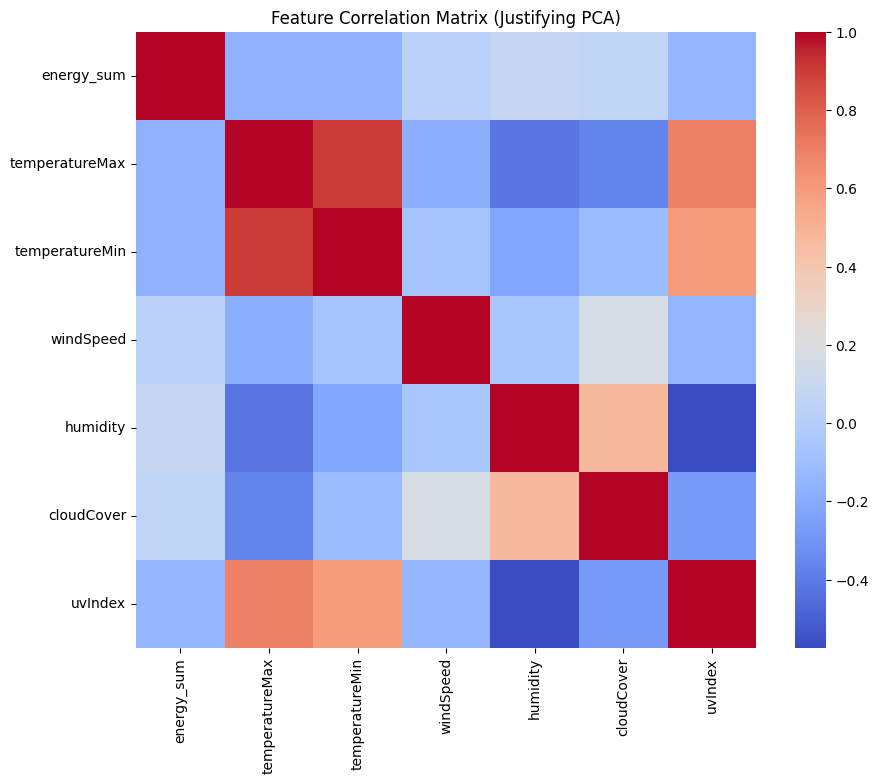

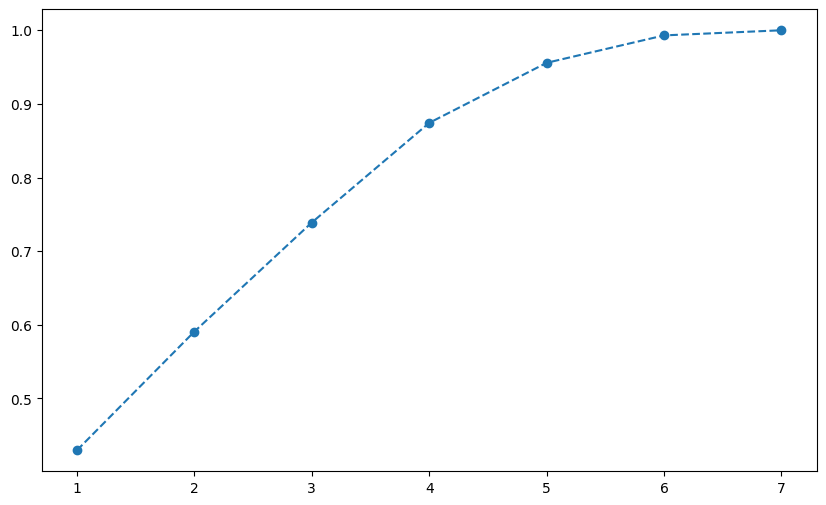

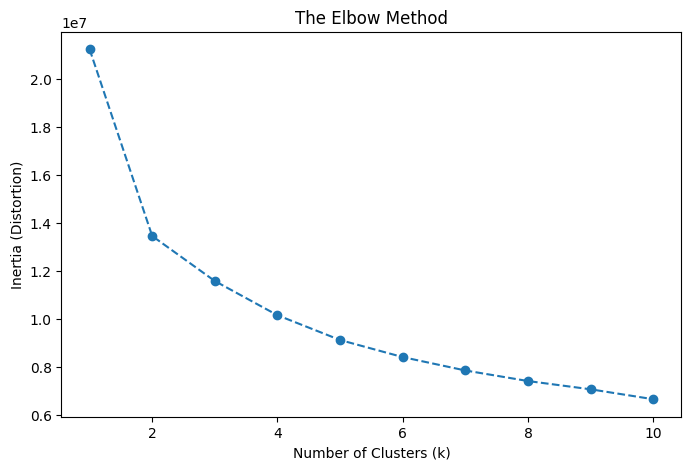

1.1971668303502518


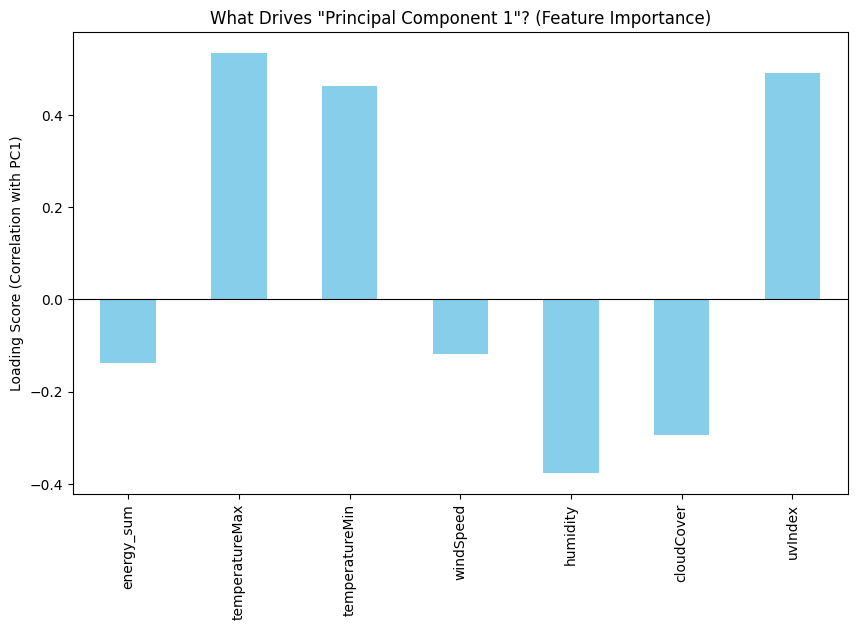

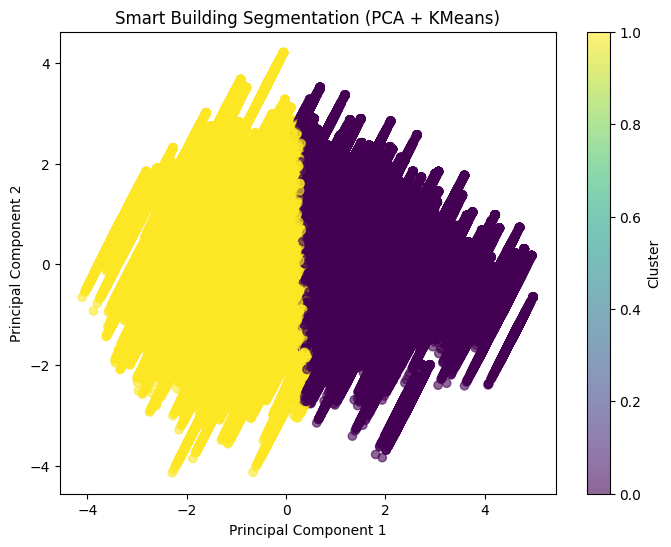

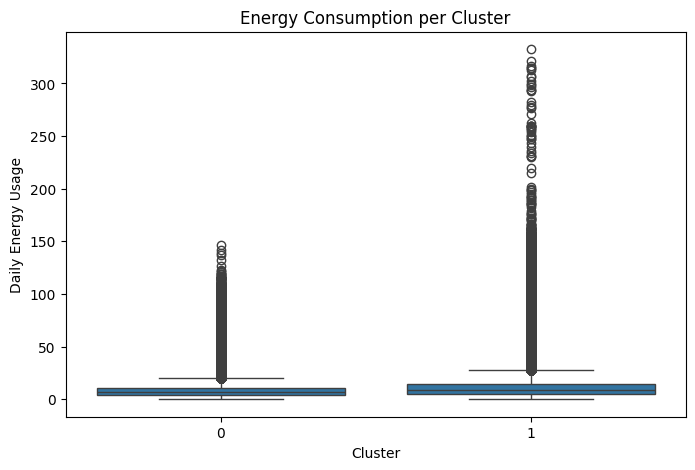

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


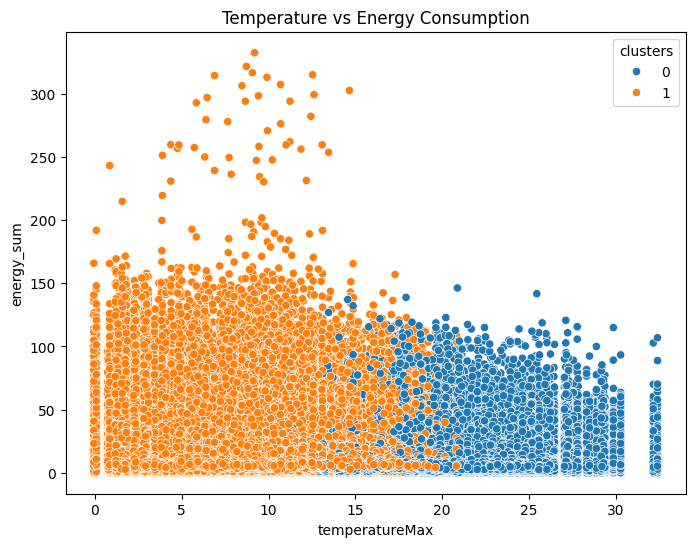

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


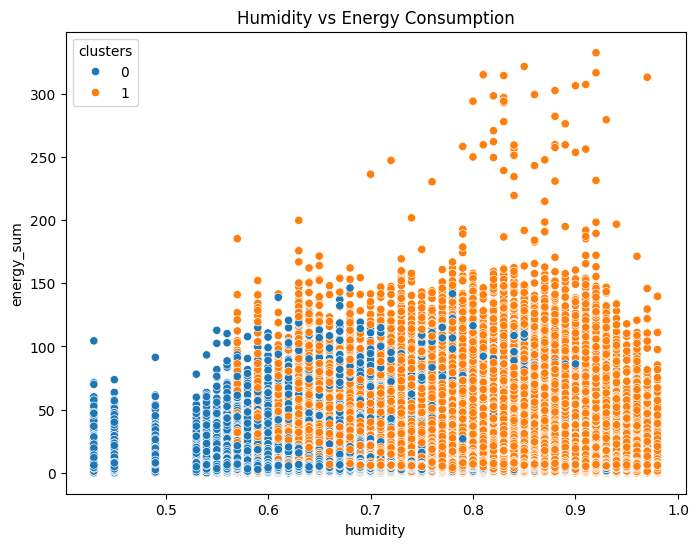

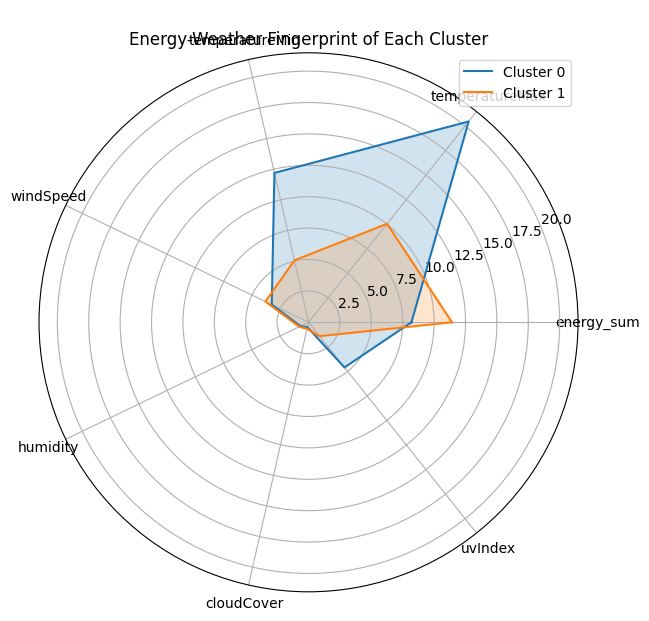

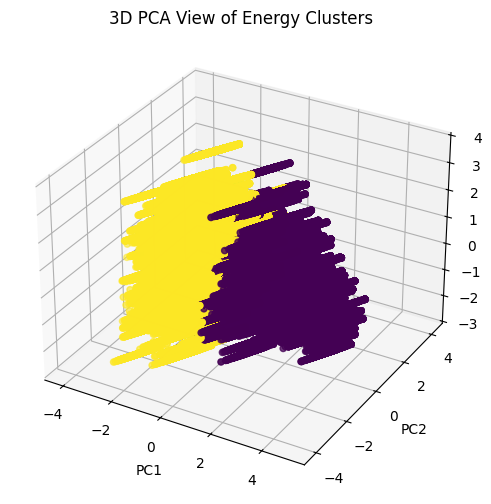

In [4]:
# Generated from: att2.ipynb
# Converted at: 2026-02-04T11:14:57.726Z
# Next step (optional): refactor into modules & generate tests with RunCell
# Quick start: pip install runcell

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import seaborn as sns
import glob
import os

acorn = pd.read_csv("/content/sample_data/energy/informations_households.csv", encoding='latin1')
# info = pd.read_csv("/content/sample_data/energy/informations_households.csv")
holidays = pd.read_csv("/content/sample_data/energy/uk_bank_holidays.csv")
weather_d = pd.read_csv("/content/sample_data/energy/weather_daily_darksky.csv")
daily = pd.read_csv("/content/sample_data/energy/daily_dataset.csv", on_bad_lines='skip') # Added on_bad_lines='skip' to handle malformed rows

# Convert 'day' column to datetime, coercing errors to NaT, then drop rows with NaT values
daily['day'] = pd.to_datetime(daily['day'], errors='coerce')
daily = daily.dropna(subset=['day'])
daily['day'] = daily['day'].dt.date

weather_d['time'] = pd.to_datetime(weather_d['time']).dt.date

merged_df = pd.merge(daily, acorn[['LCLid', 'Acorn_grouped']], on='LCLid', how='left')

final_df = pd.merge(merged_df, weather_d, left_on='day', right_on='time', how='left')

final_df.head()

final_df = final_df.dropna()

Q1 = final_df['energy_mean'].quantile(0.25)
Q3 = final_df['energy_mean'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = final_df[(final_df['energy_mean'] < lower_bound) | (final_df['energy_mean'] > upper_bound)]

print(f"Total Outliers: {len(outliers)}")
print(f"Normal range between {lower_bound:.2f} and {upper_bound:.2f}")

incomplete_rows = final_df[final_df['energy_count'] < 46]
print(f"Dropping {len(incomplete_rows)} incomplete days.")
final_df = final_df[final_df['energy_count'] == 48]



selected_features = [
    'energy_sum',
    'temperatureMax',
    'temperatureMin',
    'windSpeed',
    'humidity',
    'cloudCover',
    'uvIndex'
]
X = final_df[selected_features].copy()


plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Matrix (Justifying PCA)")
plt.show()

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import numpy as np

x_robust = RobustScaler().fit_transform(X)

X['energy_sum'] = np.log1p(X['energy_sum'])

x_standard = StandardScaler().fit_transform(X)

pca_plt=PCA()
pca_plt.fit(x_standard)
cumulative_variance = np.cumsum(pca_plt.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

#considering 4 components as optimal(close to 0.9)
pca = PCA(n_components = 4)
pca_df = pca.fit_transform(x_standard)


inertia = []
range_k = range(1, 11)

for k in range_k:
    kmeans_g = KMeans(n_clusters=k, random_state=42)
    kmeans_g.fit(pca_df)
    inertia.append(kmeans_g.inertia_)

# plotting
plt.figure(figsize=(8, 5))
plt.plot(range_k, inertia, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Distortion)')
plt.show()

kmeans = KMeans(n_clusters=2 , random_state=42)
kmeans.fit(pca_df)
y_pred = kmeans.predict(pca_df)

final_df['clusters'] = y_pred



from sklearn.metrics import davies_bouldin_score

score = davies_bouldin_score(pca_df, y_pred)
print(score)

#feature importance for each principle componenent
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose to get Features x Components
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Dynamically adjust columns based on n_components
    index=X.columns
)
plt.figure(figsize=(10, 6))
loadings['PC1'].plot(kind='bar', color='skyblue')
plt.title('What Drives "Principal Component 1"? (Feature Importance)')
plt.ylabel('Loading Score (Correlation with PC1)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()


# from sklearn.metrics import silhouette_samples

# sample_silhouette_values = silhouette_samples(pca_df, y_pred)

# y_lower = 10
# plt.figure(figsize=(10, 6))

# for i in range(2):   # because n_clusters = 2
#     ith_cluster_silhouette_values = sample_silhouette_values[y_pred == i]
#     ith_cluster_silhouette_values.sort()

#     size_cluster_i = ith_cluster_silhouette_values.shape[0]
#     y_upper = y_lower + size_cluster_i

#     plt.fill_betweenx(np.arange(y_lower, y_upper),
#                       0, ith_cluster_silhouette_values,
#                       alpha=0.7)

#     plt.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Cluster {i}")
#     y_lower = y_upper + 10

# plt.axvline(x=silhouette_avg, color="red", linestyle="--", label="Average Silhouette Score")
# plt.xlabel("Silhouette coefficient")
# plt.ylabel("Samples")
# plt.title("Silhouette Plot for Smart Building Clustering")
# plt.legend()
# plt.show()

plt.figure(figsize=(8,6))
plt.scatter(pca_df[:,0], pca_df[:,1], c=y_pred, cmap='viridis', alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Smart Building Segmentation (PCA + KMeans)")
plt.colorbar(label="Cluster")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x=final_df['clusters'], y=final_df['energy_sum'])
plt.xlabel("Cluster")
plt.ylabel("Daily Energy Usage")
plt.title("Energy Consumption per Cluster")
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(data=final_df, x='temperatureMax', y='energy_sum', hue='clusters')
plt.title("Temperature vs Energy Consumption")
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(data=final_df, x='humidity', y='energy_sum', hue='clusters')
plt.title("Humidity vs Energy Consumption")
plt.show()
print('\n')

cluster_profile = final_df.groupby('clusters')[selected_features].mean()

from math import pi

categories = selected_features
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for i in cluster_profile.index:
    values = cluster_profile.loc[i].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title("\nEnergy-Weather Fingerprint of Each Cluster")
plt.legend()
plt.show()



from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pca_df[:,0], pca_df[:,1], pca_df[:,2], c=y_pred, cmap='viridis')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA View of Energy Clusters")
plt.show()


In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df[:,0], pca_df[:,1], c=y_pred, cmap='viridis', alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Smart Building Segmentation (PCA + KMeans)")
plt.colorbar(label="Cluster")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x=final_df['clusters'], y=final_df['energy_sum'])
plt.xlabel("Cluster")
plt.ylabel("Daily Energy Usage")
plt.title("Energy Consumption per Cluster")
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(data=final_df, x='temperatureMax', y='energy_sum', hue='clusters')
plt.title("Temperature vs Energy Consumption")
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(data=final_df, x='humidity', y='energy_sum', hue='clusters')
plt.title("Humidity vs Energy Consumption")
plt.show()


cluster_profile = final_df.groupby('clusters')[selected_features].mean()

from math import pi

categories = selected_features
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for i in cluster_profile.index:
    values = cluster_profile.loc[i].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title("Energy-Weather Fingerprint of Each Cluster")
plt.legend()
plt.show()
